# The Project Drawdown World Builder
The module ```drawdown.explorer``` contains a world-building engine ```drawdown_model``` based on the FAIR v2.2.4 reduced-complexity climate model https://github.com/OMS-NetZero/FAIR.

This is very literally a world-building machine, and it runs on stories.  Tell it a story about climate solutions, and it will show you the world that results.

In [55]:
from drawdown import explorer

Import a few other useful libraries

In [56]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

## Translating stories into model input
The function ```explorer.get_input``` takes a story about the world and translates it into emissions language the model can understand.
### Decide: How are the solutions implemented in time?
First, you'll need to specify the shape of the adoption curve
The **adoption_curve** specified must be a function.  I suggest using one of four in the drawdown.explorer package:
* ```pulse```: prevent an instantaneous release
* ```linear_ramp```: continuously scale up solution, preventing additional release each year
* ```rectangular_pulse```: prevent a release over a given time duration
* ```S_curve```: emissions reductions ramp up and then saturate.



#### Rectangular_pulse parameters
* ```duration```: timespan over which pulse is sustained. Defaults to 30 years.
#### S curve parameters
The shape of the S curve is controlled by 2 additional parameters:
* ```k```: the growth rate (steepness)
~0.1 = slow, ~0.5 = moderate, ~1.0+ = fast S-curve. Defaults to 0.5
* ```years_to_half_adoption```: Years after t_start at which adoption is at 50% of L.  Controls when the S curve starts to take off.
                        Defaults to 1/4 of the remaining time window.

You can use the defaults on these parameters or change them by passing a dictionary ``` function_kwargs = {} ``` to ```explorer.input_data```.

## Other choices
* ```implementation_start```: determines when you begin implementing the solution
* ```units_adopted```: Maximum number of units adopted.
Make sure you're not confusing stocks and flows!  If the adoption curve is a pulse or rectangular pulse function, you're preventing the release of these pollutants only for them to be re-emitted the next year (in the case of a pulse) or after some duration (for a rectangular pulse).  If the adoption curve is a step function or S curve, you're assuming that once the solution is implemented you've prevented those emissions forever.


# Example: Coal Mine Methane 
This is a simple example because the solution prevents the emission of only one gas: CH$_4$. An adoption unit is 1 Mt methane avoided.  Let's look at the temperature consequences of different implementation timescales.  We'll look at three cases:
* Implementation slowly scales up beginning 2030
* Implementation quickly scales up beginning 2030
* Implementation quickly scales up beginning 2050


### Modeling choices
We'll choose an S curve for the temperature trajectory and look at the consequence of implementing a single adoption unit

In [2]:
solution = "Manage Coal Mine Methane"
adoption_curve = explorer.S_curve
units_adopted = 1
implementation_start = 2030

#### S curve parameters
To examine the consequences of different time trajectories, set the S curve parameters ```k``` and ```years_to_half_adoption``` using a dictionary:

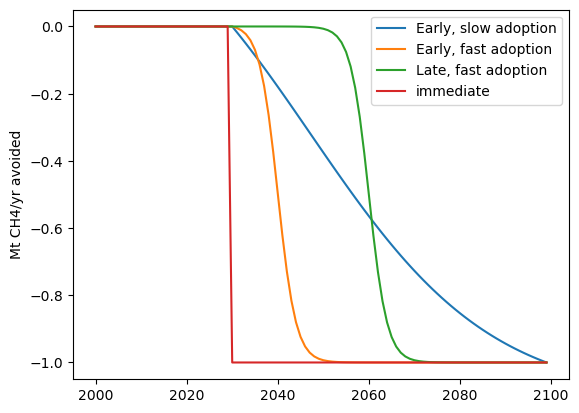

In [3]:
slow_rate=dict(k=0.05)
fast_rate = dict(k=0.5,years_to_half_adoption=10)
late_adoption = dict(k=0.5,years_to_half_adoption=30)

# dummy time points
timepoints = np.arange(2000,2100,1)
plt.plot(timepoints,-explorer.S_curve(timepoints,2030,1,**slow_rate),label="Early, slow adoption")
plt.plot(timepoints,-explorer.S_curve(timepoints,2030,1,**fast_rate),label="Early, fast adoption")
plt.plot(timepoints,-explorer.S_curve(timepoints,2030,1,**late_adoption),label="Late, fast adoption")
plt.plot(timepoints,-explorer.step_function(timepoints,2030,1),label="immediate")
plt.ylabel("Mt CH4/yr avoided")
plt.legend()

Now, let's get the input emissions dictionaries for these scenarios.

In [4]:
early_slow=explorer.get_input(solution,
                     adoption_curve,
                     units_adopted=units_adopted,
                     implementation_start=implementation_start,
                     function_kwargs=slow_rate,
                             scenario_name="Early, slow adoption")
early_fast=explorer.get_input(solution,
                     adoption_curve,
                     units_adopted=units_adopted,
                     implementation_start=implementation_start,
                     function_kwargs=fast_rate,
                             scenario_name="Early, fast adoption")

late_fast=explorer.get_input(solution,
                     adoption_curve,
                     units_adopted=units_adopted,
                     implementation_start=2030,
                     function_kwargs=late_adoption,
                             scenario_name="Late, fast adoption")
immediate=explorer.get_input(solution,
                     explorer.step_function,
                     units_adopted=1,
                     implementation_start=2030,
                            scenario_name="immediate")

## The climate model
Now run the drawdown model with a constant emissions baseline scenario and these perturbation dictionaries.  The ```lite``` keyword runs 10 configurations (rather than the entire 841 member ensemble) to cut down on memory use.  Use ```lite=False``` for publication-quality figures and full uncertainty analysis.

In [5]:
methanemodel=explorer.drawdown_model("constant",perturbation_dicts=early_slow | early_fast | late_fast | immediate, lite=True)

Running 50 projections in parallel:   0%|          | 0/352 [00:00<?, ?timesteps/s]

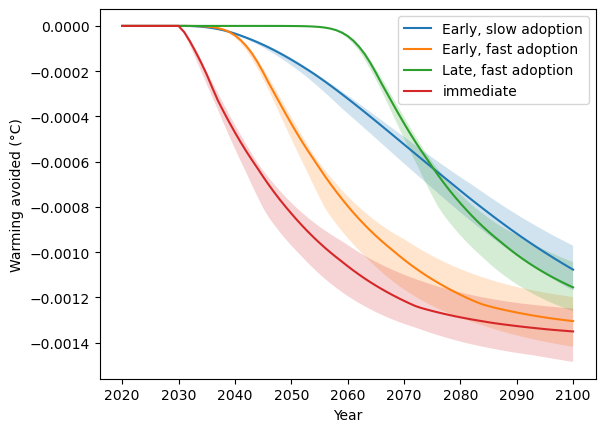

In [6]:
explorer.plot_T_diff(methanemodel)

# Example: Protecting Peatlands
Now let's do an example of a solution that mitigates multiple greenhouse gases.  We'll read in the data from the Protect Peatlands solution for boreal, temperate, subtropical, and tropical regions.

Questions:
1. Do we need an option to have different trajectories for different pollutants? Eg for protecting peatlands do we use a rectangular pulse for carbon but a step function for methane?  
2. What do we do with the learning curves, current adoptions, adoption trends, adoption ceilings, and adoption range?  What's the most user-friendly way to plug in this information?

Instead of a single unit, we'll use the adoption ceilings reported in the spreadsheets.  

In [27]:


adoption_df=pd.read_csv(explorer._DATA_DIR/"emissions/solutions/adoption.csv")
adoption_ceiling = lambda solution: float(adoption_df[adoption_df["solution name"] == solution].adoption_ceiling_mean.values[0])

Now let's assume that once we protect a peatland, we prevent its emissions forever (whereas in the baseline scenario that peatland would be gone forever).

In [32]:
# Example: Protecting Peatlands Forever
d={}
regions=["Boreal","Temperate","Subtropical","Tropical"]
for region in regions:
    solution = "Protect Peatlands "+region
    d=d | explorer.get_input(solution,
              adoption_curve=explorer.step_function,#explorer.rectangular_pulse,
              land=True,
              units_adopted = adoption_ceiling(solution),
              implementation_start=2030,
                            scenario_name=solution+" forever")

In [33]:
peatforever=explorer.drawdown_model("constant",d,lite=True)

Running 50 projections in parallel:   0%|          | 0/352 [00:00<?, ?timesteps/s]

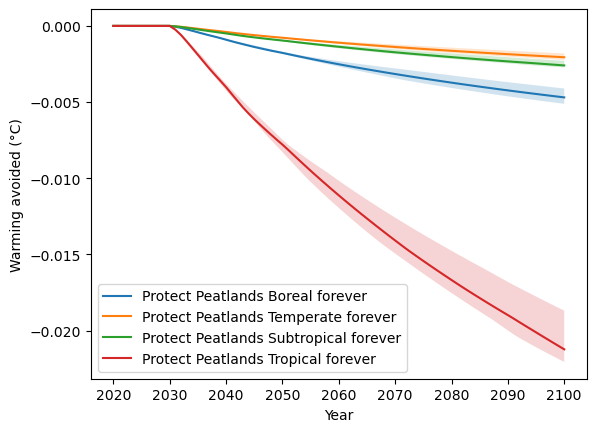

In [34]:
explorer.plot_T_diff(peatforever)

Now suppose the peatland in the reference scenario would restore itself after 30 years.  Rectangular pulse prevents (adoption ceiling * emissions_per_unit)/30 emissions per year.  Jamie, please verify this is what I should be using to match the current solution treatment?

In [21]:
# Example: Protecting Peatlands For 30 years
d30={}
regions=["Boreal","Temperate","Subtropical","Tropical"]
for region in regions:
    solution = "Protect Peatlands "+region
    d30=d30 | explorer.get_input(solution,
              adoption_curve=explorer.rectangular_pulse,
              land=True,
              units_adopted = adoption_ceiling(solution),
              implementation_start=2030,
                            function_kwargs=dict(duration=30))

In [37]:
peat30=explorer.drawdown_model("constant",d30,lite=True)

Running 50 projections in parallel:   0%|          | 0/352 [00:00<?, ?timesteps/s]

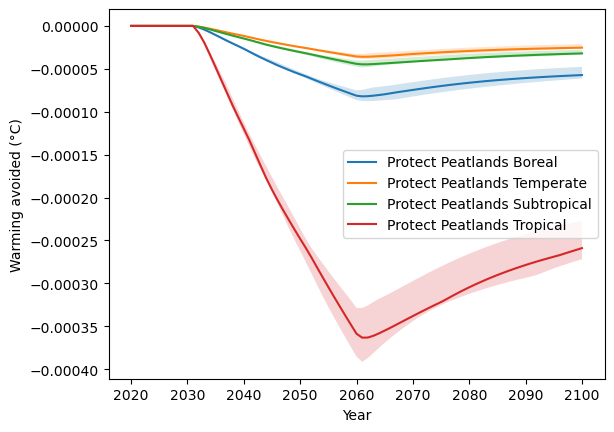

In [38]:
explorer.plot_T_diff(peat30)

# Example: Power Sector
As a sanity check, let's check the temperature impact of adding 1MW installed capacity of all our power sector solution


In [40]:
d_elec={}
solutions=['Deploy Distributed Solar PV',
           'Deploy Utility-Scale Solar PV',
           'Deploy Offshore Wind Turbines',
           'Deploy Onshore Wind Turbines']
for solution in solutions:
    
    d_elec=d_elec | explorer.get_input(solution,
              adoption_curve=explorer.step_function,
              units_adopted = 1,
              implementation_start=2030)

### Run the Drawdown model

In [41]:
electricity=explorer.drawdown_model("constant",d_elec,lite=True)

Running 50 projections in parallel:   0%|          | 0/352 [00:00<?, ?timesteps/s]

Wind solutions have the largest warming reduction (because the capacity factors of wind are higher than solar, so you get more clean power from 1MW wind than from 1MW solar)

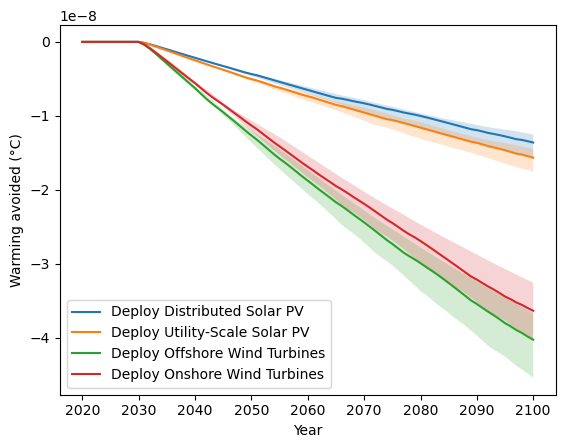

In [42]:
explorer.plot_T_diff(electricity)

We can use the data utils in the package to check this.  The functions in  ```utils.zenodo``` module download and process publicly available spreadsheets on the Project Drawdown Explorer zenodo site: https://zenodo.org/communities/pdexplorer/records?q=&l=list&p=1&s=10&sort=newest

In [43]:
from utils import zenodo

In [53]:
CF={}
for solution in solutions:
    #Grab the spreadsheet- it'll download it to ../data/zenodo_spreadsheets if you don't already have it
    xlsx_path = zenodo.download_solution_spreadsheet(solution)
    
    df = pd.read_excel(xlsx_path, sheet_name="2. current state effectiveness", header=None)
    # Pull out the capacity factors from the standardized spreadsheets 
    row_idx = df.index[df.iloc[:, 0] == "Capacity factor"][0]
    capacity_df=df[row_idx:]
    median=capacity_df[capacity_df.iloc[:,0]=="median"].iloc[0,1]
    p25=capacity_df[capacity_df.iloc[:,0]=="25th percentile"].iloc[0,1]
    p75=capacity_df[capacity_df.iloc[:,0]=="75th percentile"].iloc[0,1]
    CF[solution]=(median,p25,p75)


In [54]:
CF

{'Deploy Distributed Solar PV': (0.14, 0.14, 0.14),
 'Deploy Utility-Scale Solar PV': (0.1617092776, 0.1617092776, 0.1617092776),
 'Deploy Offshore Wind Turbines': (0.4104074502, 0.4104074502, 0.4104074502),
 'Deploy Onshore Wind Turbines': (0.370594, 0.33, 0.43)}